In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# explanatory analysis
Load data CRMLSListing202602.csv
Load data CRMLSSold202602


In [4]:
df_listing = pd.read_csv("data/mergedListing_24_26.csv")
print(df_listing.head()) # First 5 rows


C:\Users\14012\AppData\Local\Temp\ipykernel_113924\1072340040.py:1: DtypeWarning: Columns (0: ListAgentEmail, 1: BuyerAgencyCompensationType) have mixed types. Specify dtype option on import or set low_memory=False.
  df_listing = pd.read_csv("data/mergedListing_24_26.csv")


   OriginalListPrice  ListingKey                        ListAgentEmail  \
0            90000.0  1075010398                miriamlara03@gmail.com   
1          1500000.0  1074974457                  janelle@judsonre.com   
2          1340000.0  1074973329                    haleh360@Gmail.com   
3          2500000.0  1074954552  Reneechen@yourhomesoldguaranteed.com   
4          3150000.0  1074936537                      anader@dppre.com   

  CloseDate  ClosePrice ListAgentFirstName ListAgentLastName   Latitude  \
0       NaN         NaN             Miriam              Lara  34.097939   
1       NaN         NaN            Janelle            Judson  33.121241   
2       NaN         NaN              Haleh       Dowlatshahi  34.052207   
3       NaN         NaN              Renee              Chen  33.496363   
4       NaN         NaN           Margaret             Nader  34.119345   

    Longitude                UnparsedAddress  ... MainLevelBedrooms  \
0 -117.909653                1045

In [7]:
print(df_listing.shape)
print(df_listing.columns)# shape of listing

(852963, 84)
Index(['OriginalListPrice', 'ListingKey', 'ListAgentEmail', 'CloseDate',
       'ClosePrice', 'ListAgentFirstName', 'ListAgentLastName', 'Latitude',
       'Longitude', 'UnparsedAddress', 'PropertyType', 'LivingArea',
       'ListPrice', 'DaysOnMarket', 'ListOfficeName', 'BuyerOfficeName',
       'CoListOfficeName', 'ListAgentFullName', 'CoListAgentFirstName',
       'CoListAgentLastName', 'BuyerAgentMlsId', 'BuyerAgentFirstName',
       'BuyerAgentLastName', 'FireplacesTotal', 'AssociationFeeFrequency',
       'AboveGradeFinishedArea', 'ListingKeyNumeric', 'MLSAreaMajor',
       'TaxAnnualAmount', 'CountyOrParish', 'PropertyType.1', 'MlsStatus',
       'ElementarySchool', 'ListAgentFirstName.1', 'AttachedGarageYN',
       'ParkingTotal', 'BuilderName', 'PropertySubType', 'LotSizeAcres',
       'SubdivisionName', 'BuyerOfficeAOR', 'YearBuilt', 'DaysOnMarket.1',
       'BuyerAgencyCompensationType', 'StreetNumberNumeric', 'LivingArea.1',
       'ListingId', 'BathroomsTotalI

In [8]:
df_sold = pd.read_csv("data/merged_sold_24_26.csv")
print(df_sold.head())# First 5 rows of sold


C:\Users\14012\AppData\Local\Temp\ipykernel_113924\784731106.py:1: DtypeWarning: Columns (0: BuyerAgentAOR, 1: ListAgentAOR, 2: WaterfrontYN, 3: ListAgentEmail, 4: OriginatingSystemName, 5: OriginatingSystemSubName, 6: BuyerAgencyCompensationType) have mixed types. Specify dtype option on import or set low_memory=False.
  df_sold = pd.read_csv("data/merged_sold_24_26.csv")


              BuyerAgentAOR              ListAgentAOR          Flooring  \
0               Mlslistings               Mlslistings  Carpet,Tile,Wood   
1                HighDesert                HighDesert               NaN   
2              OrangeCounty              OrangeCounty               NaN   
3             InlandValleys             InlandValleys               NaN   
4  SouthwestRiversideCounty  SouthwestRiversideCounty               NaN   

  ViewYN WaterfrontYN BasementYN PoolPrivateYN  OriginalListPrice  ListingKey  \
0   True          NaN        NaN         False           499000.0   551985747   
1    NaN          NaN        NaN           NaN                0.0   535486633   
2   True          NaN        NaN           NaN            75000.0   529986282   
3   True          NaN        NaN           NaN           199000.0   529618166   
4   True          NaN        NaN           NaN            19500.0   522614340   

               ListAgentEmail  ... PostalCode  AssociationFee 

In [10]:
print(df_sold.shape) # shape of sold
print(df_sold.columns)

(591733, 84)
Index(['BuyerAgentAOR', 'ListAgentAOR', 'Flooring', 'ViewYN', 'WaterfrontYN',
       'BasementYN', 'PoolPrivateYN', 'OriginalListPrice', 'ListingKey',
       'ListAgentEmail', 'CloseDate', 'ClosePrice', 'ListAgentFirstName',
       'ListAgentLastName', 'Latitude', 'Longitude', 'UnparsedAddress',
       'PropertyType', 'LivingArea', 'ListPrice', 'DaysOnMarket',
       'ListOfficeName', 'BuyerOfficeName', 'CoListOfficeName',
       'ListAgentFullName', 'CoListAgentFirstName', 'CoListAgentLastName',
       'BuyerAgentMlsId', 'BuyerAgentFirstName', 'BuyerAgentLastName',
       'FireplacesTotal', 'AssociationFeeFrequency', 'AboveGradeFinishedArea',
       'ListingKeyNumeric', 'MLSAreaMajor', 'TaxAnnualAmount',
       'CountyOrParish', 'MlsStatus', 'ElementarySchool', 'AttachedGarageYN',
       'ParkingTotal', 'BuilderName', 'PropertySubType', 'LotSizeAcres',
       'SubdivisionName', 'BuyerOfficeAOR', 'YearBuilt', 'StreetNumberNumeric',
       'ListingId', 'BathroomsTotalIntege

## Check Missing

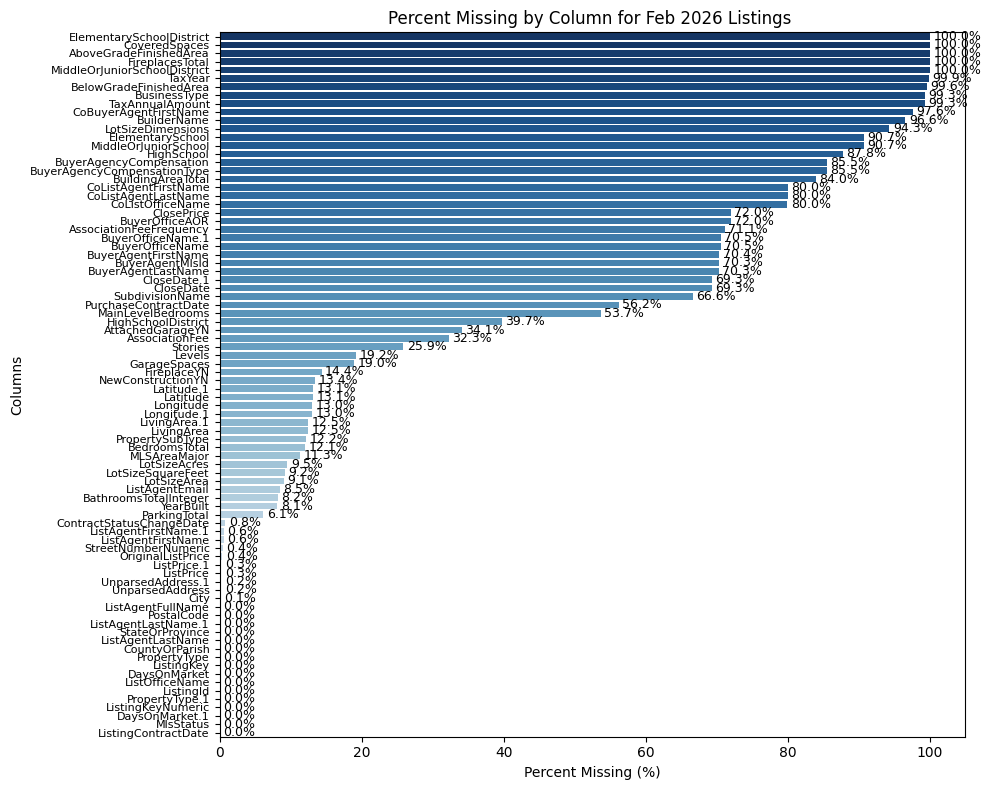

In [11]:
missing_pct = df_listing.isnull().sum() / df_listing.shape[0] *100
missing_df = missing_pct.reset_index()
missing_df.columns = ["column", "percent_missing"]
missing_df = missing_df.sort_values("percent_missing", ascending=False) # sort from high to low
# plot
plt.figure(figsize=(10, 8))
ax = sns.barplot(data=missing_df, y="column", x="percent_missing", hue = "column", palette = "Blues_r")

# add text labels
for i, v in enumerate(missing_df["percent_missing"]):
    ax.text(v + 0.5, i, f"{v:.1f}%", va="center", fontsize=9)

plt.xlabel("Percent Missing (%)")
plt.ylabel("Columns")
plt.title("Percent Missing by Column for Feb 2026 Listings ")
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()



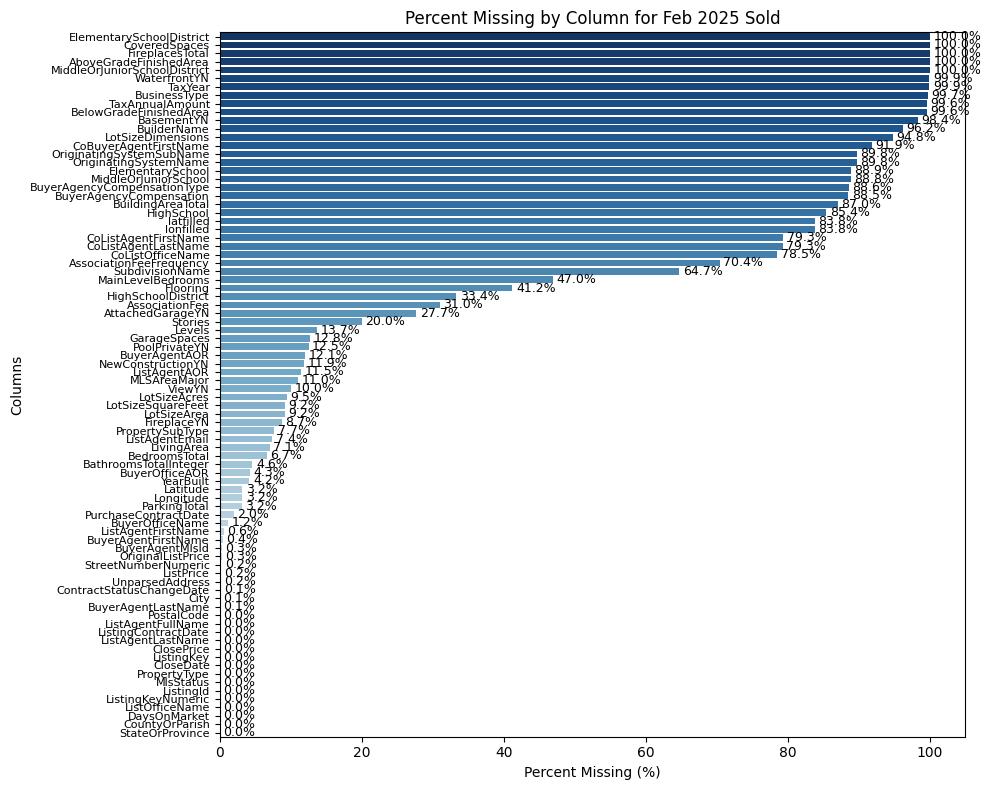

In [12]:
missing_pct = df_sold.isnull().sum() / df_sold.shape[0] *100
missing_df = missing_pct.reset_index()
missing_df.columns = ["column", "percent_missing"]
missing_df = missing_df.sort_values("percent_missing", ascending=False) # sort from high to low
# plot
plt.figure(figsize=(10, 8))
ax = sns.barplot(data=missing_df, y="column", x="percent_missing", hue = "column", palette = "Blues_r")

# add text labels
for i, v in enumerate(missing_df["percent_missing"]):
    ax.text(v + 0.5, i, f"{v:.1f}%", va="center", fontsize=9)

plt.xlabel("Percent Missing (%)")
plt.ylabel("Columns")
plt.title("Percent Missing by Column for Feb 2025 Sold")
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

The categories with less missing percent is probably more important for people who wants to buy the listing.